Epoch 1/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 56s 10ms/step - loss: 15795.4717 - mae: 51.7295 - val_loss: 167.3259 - val_mae: 9.5785
Epoch 2/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 330.0956 - mae: 14.2170 - val_loss: 176.2106 - val_mae: 10.4077
Epoch 3/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 297.7162 - mae: 13.4337 - val_loss: 133.8514 - val_mae: 6.9761
Epoch 4/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 290.4716 - mae: 13.2326 - val_loss: 361.5259 - val_mae: 17.0968
Epoch 5/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 295.7576 - mae: 13.3218 - val_loss: 237.2589 - val_mae: 12.9626
Epoch 6/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 304.3507 - mae: 13.5458 - val_loss: 139.7882 - val_mae: 6.9878
Epoch 7/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 322.8763 - mae: 14.0458 - val_loss: 181.7443 - val_mae: 10.5266
Epoch 8/50
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 331.9775 - mae: 14.2673 - val_loss: 129.2005 - v

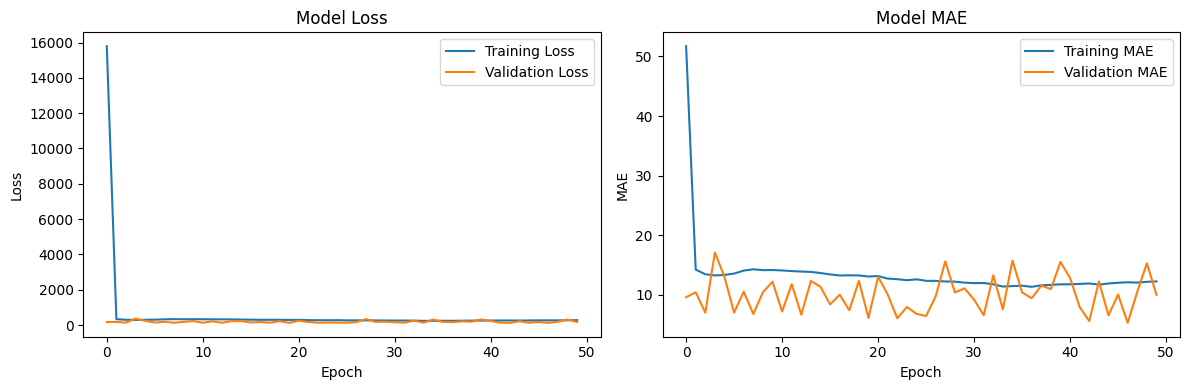

In [5]:
# notebooks/03_predictive_modeling.ipynb
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Configure TensorFlow to use GPU memory more efficiently
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

movies_clean = pd.read_csv('/Users/taksheel.partap/Desktop/CineMatch/data/cleaned_movies.csv')

# Prepare data for modeling
model_data = movies_clean.dropna(subset=['audienceScore', 'tomatoMeter', 'runtimeMinutes'])

# Feature selection
features = ['runtimeMinutes', 'scoreDifference', 'releaseYear']
X = model_data[features]
y = model_data['consensusScore']  # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
def build_hybrid_model(input_dim):
    # Input layer
    inputs = Input(shape=(input_dim,))
    
    # Smaller hidden layers
    x = Dense(32, activation='relu')(inputs)  # Reduced from 64
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)       # Reduced from 32
    x = Dropout(0.2)(x)
    
    # Output layer
    output = Dense(1, activation='linear')(x)
    
    # Create model
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    
    return model

# Initialize and train model
model = build_hybrid_model(X_train.shape[1])
# Use smaller batch size
history = model.fit(X_train, y_train, 
                   epochs=50, 
                   batch_size=16,          # Reduced from 32
                   validation_split=0.2,
                   verbose=1)

# Evaluate model
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Performance:")
print(f"MAE: {mean_absolute_error(y_train, train_pred):.2f}")
print(f"R²: {r2_score(y_train, train_pred):.2f}")

print("\nTest Performance:")
print(f"MAE: {mean_absolute_error(y_test, test_pred):.2f}")
print(f"R²: {r2_score(y_test, test_pred):.2f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Devices: ", tf.config.experimental.list_physical_devices())

TensorFlow version: 2.16.2
Num GPUs Available:  1
Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
